In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import unyt as u

import dev
import richio
from dev import SNAPSHOT_TFB


## 1e4

In [2]:
tde_1e4 = dev.TDEBasics(Mbh=1e4*u.Msun, Mstar=0.5*u.Msun, Rstar=0.47*u.Rsun, beta=1)
requested_tfbs_1e4 = [0.5, 1.0, 1.5, 2.0]
selected_1e4 = [(*SNAPSHOT_TFB("1e4", tfb), False) for tfb in requested_tfbs_1e4]
snapnums_1e4, paths_1e4 = dev.DATAPATHS("1e4")
selected_1e4.append((snapnums_1e4[-1], paths_1e4[-1], True))

profiles_1e4 = []
for snapnum, path, is_last in selected_1e4:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e4.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e4.r_p, r_stop=4 * tde_1e4.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    r_a = tde_1e4.r_a * time_tfb**(2/3)
    within_r_a = R <= r_a
    dissipation_weights = (snap.dissipation * snap.volume)[within_r_a]
    Rdiss = np.sum(dissipation_weights * R[within_r_a]) / np.sum(dissipation_weights)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    dEdiss_dr_at_r_a = np.interp(
        r_a.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e4.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
        "r_a": r_a, "dEdiss_dr_at_r_a": dEdiss_dr_at_r_a,
    })

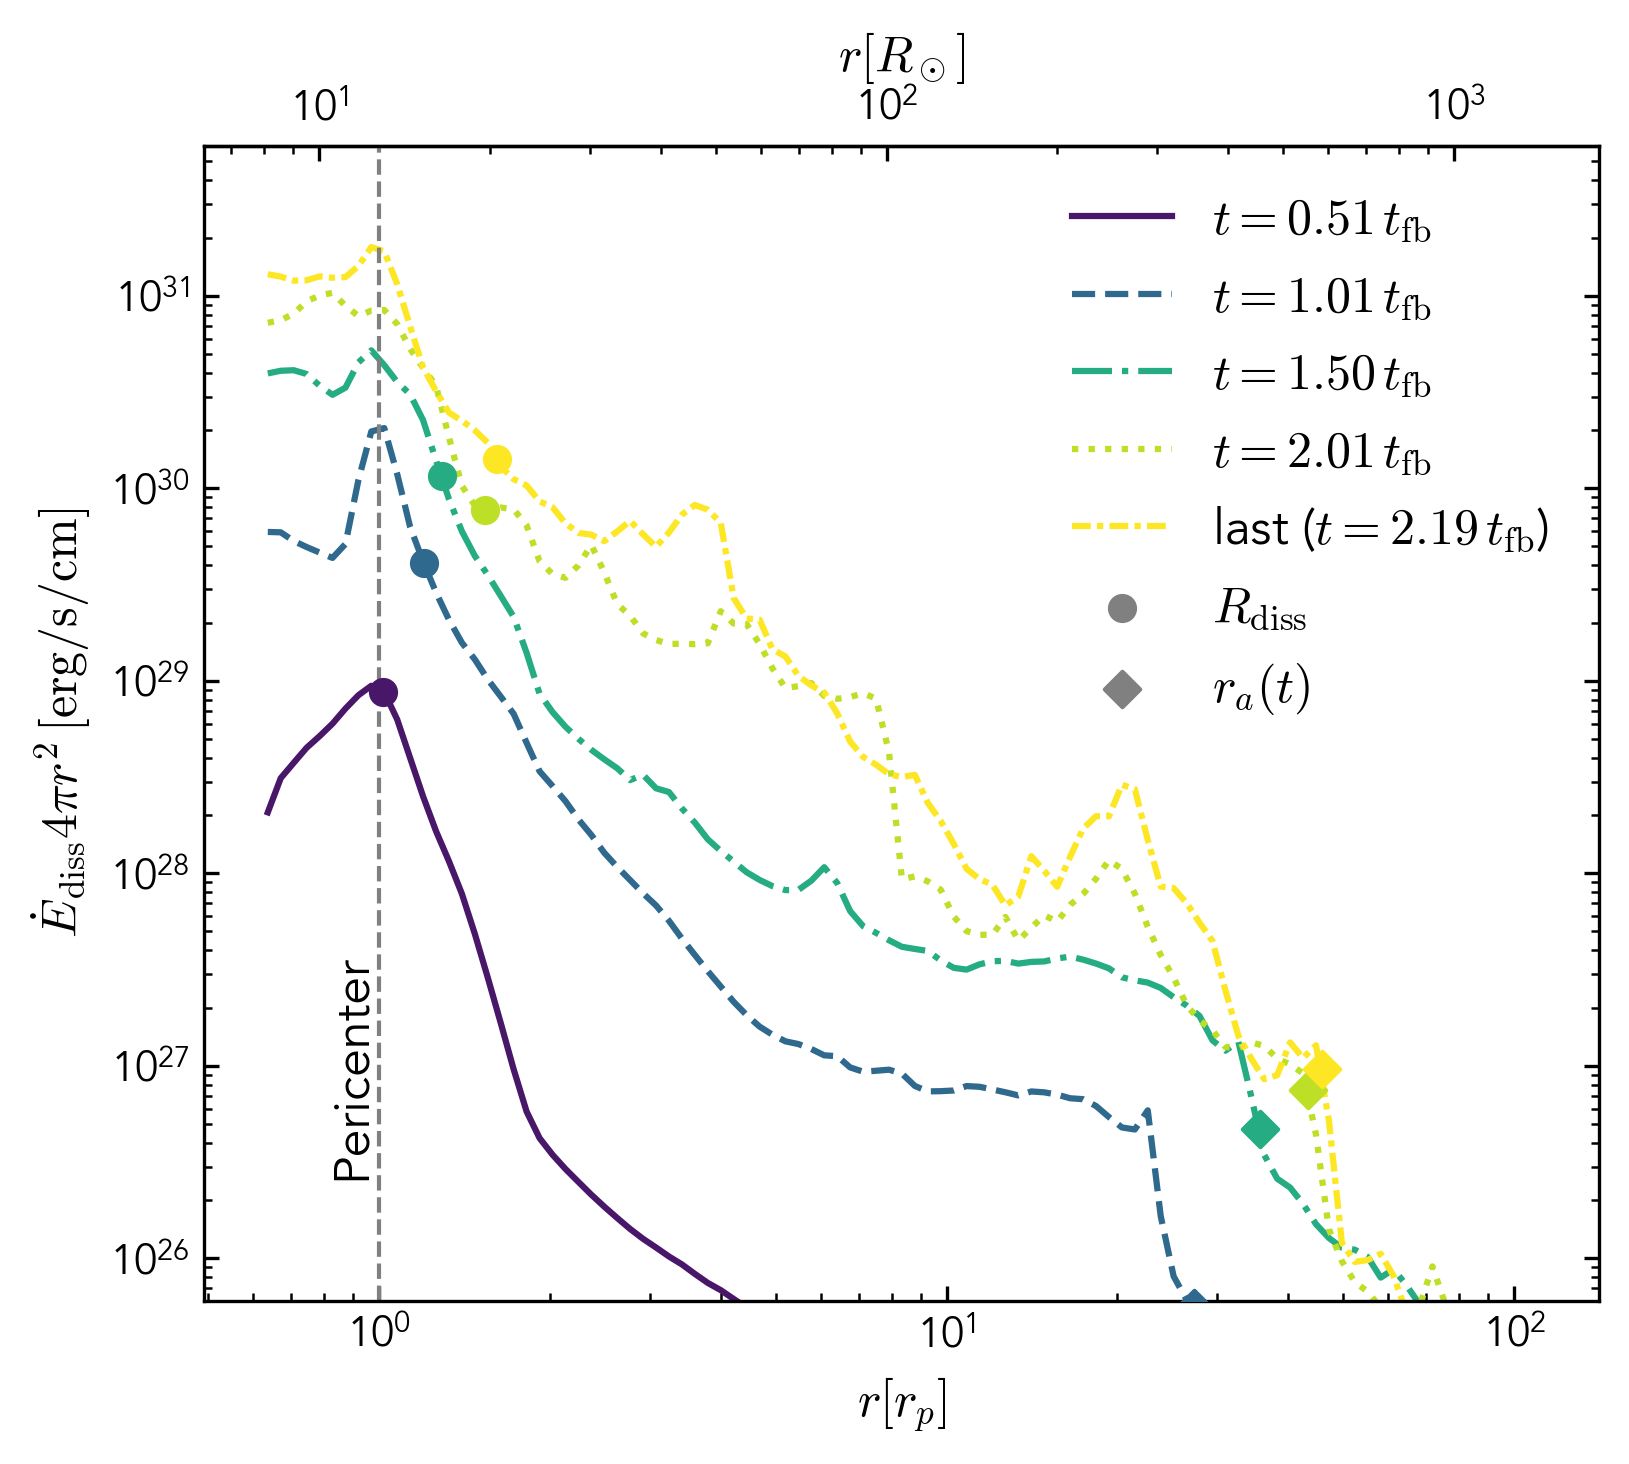

In [9]:
def add_radius_top_axis(axis, r_p):
    r_p_rsun = r_p.to_value(u.Rsun)
    axis.tick_params(axis="x", which="both", top=False)
    top_axis = axis.secondary_xaxis(
        "top",
        functions=(
            lambda radius_rp: radius_rp * r_p_rsun,
            lambda radius_rsun: radius_rsun / r_p_rsun,
        ),
    )
    top_axis.set_xlabel(r"$r[R_\odot]$")


fig, axes = plt.subplots(figsize=(6, 5), dpi=300)
tfb_cmap = plt.cm.viridis
tfb_norm = plt.Normalize(
    vmin=0.4, vmax=max(profile["time_tfb"] for profile in profiles_1e4)
)
line_styles = ("-", "--", "-.", ":", (0, (3, 1, 1, 1)))
for index, profile in enumerate(profiles_1e4):
    color = tfb_cmap(tfb_norm(profile["time_tfb"]))
    linestyle = line_styles[index % len(line_styles)]
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    plt.plot(
        (profile["r"] / tde_1e4.r_p).to_value(), profile["dEdiss_dr"],
        color=color, linestyle=linestyle, linewidth=1.5, label=label,
    )
    plt.scatter(
        (profile["Rdiss"] / tde_1e4.r_p).to_value(),
        profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )
    plt.scatter(
        (profile["r_a"] / tde_1e4.r_p).to_value(),
        profile["dEdiss_dr_at_r_a"],
        color=color, marker='D', zorder=3,
    )

plt.scatter([], [], color='gray', marker='o', label=r"$R_\mathrm{diss}$")
plt.scatter([], [], color='gray', marker='D', label=r"$r_a(t)$")
plt.axvline(1, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(1, 0.3),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
y_max = axes.get_ylim()[1]
axes.set_ylim(y_max / 1e6, y_max)
plt.ylabel(r"$\dot{E}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[r_p]$")
add_radius_top_axis(axes, tde_1e4.r_p)
plt.legend()
plt.show()

## 1e5

In [4]:
tde_1e5 = dev.TDEBasics(Mbh=1e5*u.Msun, Mstar=0.5*u.Msun, Rstar=0.47*u.Rsun, beta=1)
requested_tfbs_1e5 = [0.4, 0.5]
selected_1e5 = [(*SNAPSHOT_TFB("1e5", tfb), False) for tfb in requested_tfbs_1e5]
snapnums_1e5, paths_1e5 = dev.DATAPATHS("1e5")
selected_1e5.append((snapnums_1e5[-1], paths_1e5[-1], True))

profiles_1e5 = []
for snapnum, path, is_last in selected_1e5:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e5.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e5.r_p, r_stop=4 * tde_1e5.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    r_a = tde_1e5.r_a * time_tfb**(2/3)
    within_r_a = R <= r_a
    dissipation_weights = (snap.dissipation * snap.volume)[within_r_a]
    Rdiss = np.sum(dissipation_weights * R[within_r_a]) / np.sum(dissipation_weights)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    dEdiss_dr_at_r_a = np.interp(
        r_a.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e5.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
        "r_a": r_a, "dEdiss_dr_at_r_a": dEdiss_dr_at_r_a,
    })

39.45741032786038 code_length
27.333246189436313 code_length
25.99916184461373 code_length


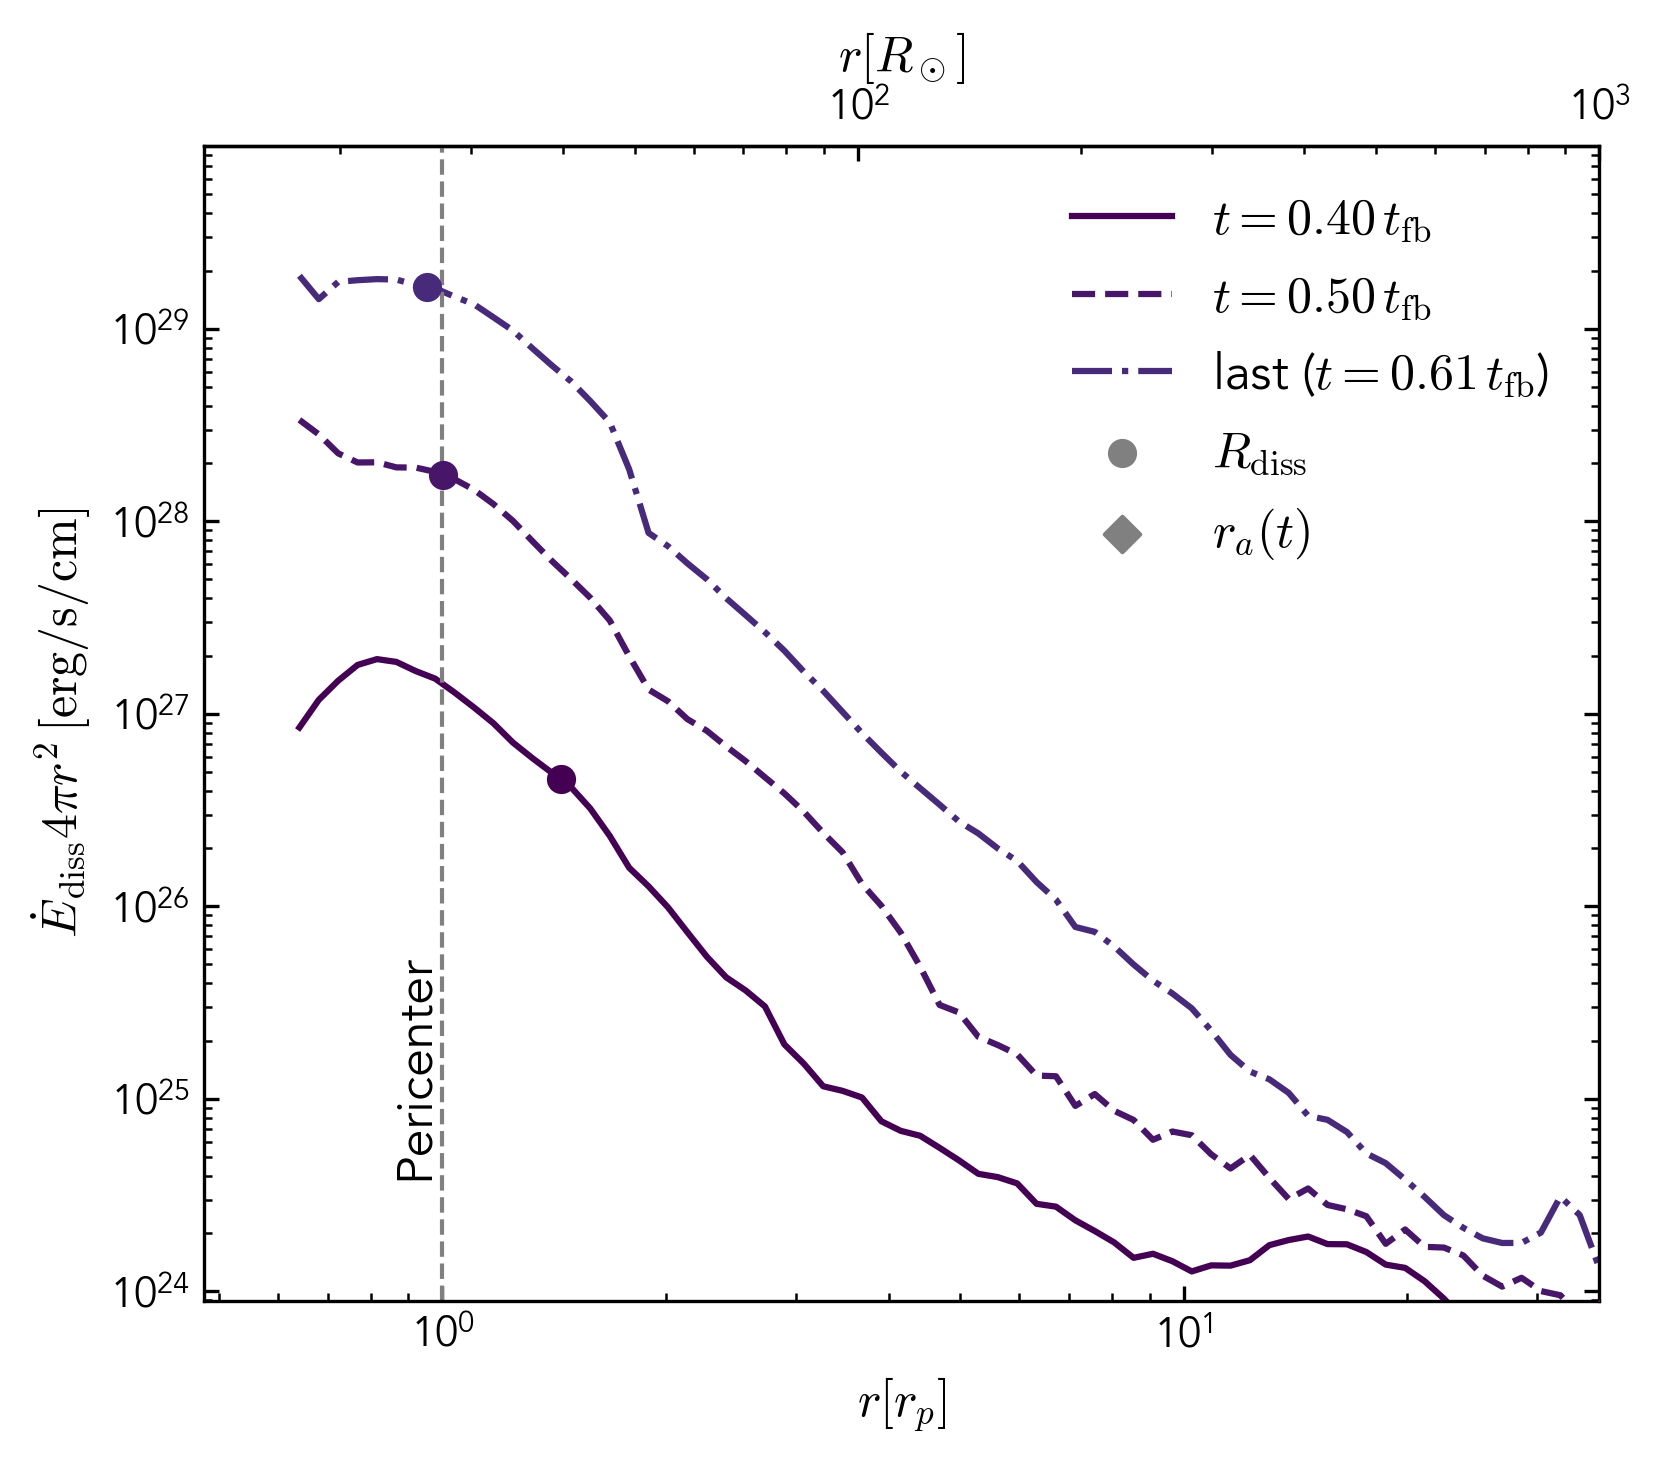

In [10]:
fig, axes = plt.subplots(figsize=(6, 5), dpi=300)
for index, profile in enumerate(profiles_1e5):
    color = tfb_cmap(tfb_norm(profile["time_tfb"]))
    linestyle = line_styles[index % len(line_styles)]
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    # Cut out spurious dissipation
    plt.plot(
        (profile["r"] / tde_1e5.r_p).to_value(), profile["dEdiss_dr"],
        color=color, linestyle=linestyle, linewidth=1.5, label=label,
    )
    print(profile["Rdiss"])
    plt.scatter(
        (profile["Rdiss"] / tde_1e5.r_p).to_value(),
        profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )
    plt.scatter(
        (profile["r_a"] / tde_1e5.r_p).to_value(),
        profile["dEdiss_dr_at_r_a"],
        color=color, marker='D', zorder=3,
    )

plt.scatter([], [], color='gray', marker='o', label=r"$R_\mathrm{diss}$")
plt.scatter([], [], color='gray', marker='D', label=r"$r_a(t)$")
plt.axvline(1, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(1, 0.3),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
y_max = axes.get_ylim()[1]
axes.set_ylim(y_max / 1e6, y_max)
axes.set_xlim(right=(1e3 * u.Rsun / tde_1e5.r_p).to_value())
plt.ylabel(r"$\dot{E}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[r_p]$")
add_radius_top_axis(axes, tde_1e5.r_p)
plt.legend()
plt.show()

## 1e6

In [6]:
tde_1e6 = dev.TDEBasics(Mbh=1e6*u.Msun, Mstar=1*u.Msun, Rstar=1*u.Rsun, beta=1)
requested_tfbs_1e6 = [1.0, 1.2, 1.4, 1.5]
selected_1e6 = [(*SNAPSHOT_TFB("1e6", tfb), False) for tfb in requested_tfbs_1e6]
snapnums_1e6, paths_1e6 = dev.DATAPATHS("1e6")
selected_1e6.append((snapnums_1e6[-1], paths_1e6[-1], True))

In [7]:
profiles_1e6 = []
for snapnum, path, is_last in selected_1e6:
    snap = richio.load(path)
    time_tfb = float(np.asarray((snap.time / tde_1e6.t_fb).to_value()).squeeze())
    Ediss, r = snap.profile(
        data="dissipation", weights="volume",
        r_start=0.6 * tde_1e6.r_p, r_stop=4 * tde_1e6.r_a,
    )
    dEdiss_dr = (Ediss * 4 * np.pi * r**2).in_cgs()
    R = np.sqrt(snap.X**2 + snap.Y**2 + snap.Z**2)
    r_a = tde_1e6.r_a * time_tfb**(2/3)
    within_r_a = R <= r_a
    dissipation_weights = (snap.dissipation * snap.volume)[within_r_a]
    Rdiss = np.sum(dissipation_weights * R[within_r_a]) / np.sum(dissipation_weights)
    dEdiss_dr_at_Rdiss = np.interp(
        Rdiss.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    dEdiss_dr_at_r_a = np.interp(
        r_a.to_value(r.units), r.to_value(), dEdiss_dr.to_value()
    ) * dEdiss_dr.units
    profiles_1e6.append({
        "snapnum": snapnum, "time_tfb": time_tfb, "is_last": is_last,
        "r": r, "dEdiss_dr": dEdiss_dr, "Rdiss": Rdiss,
        "dEdiss_dr_at_Rdiss": dEdiss_dr_at_Rdiss,
        "r_a": r_a, "dEdiss_dr_at_r_a": dEdiss_dr_at_r_a,
    })

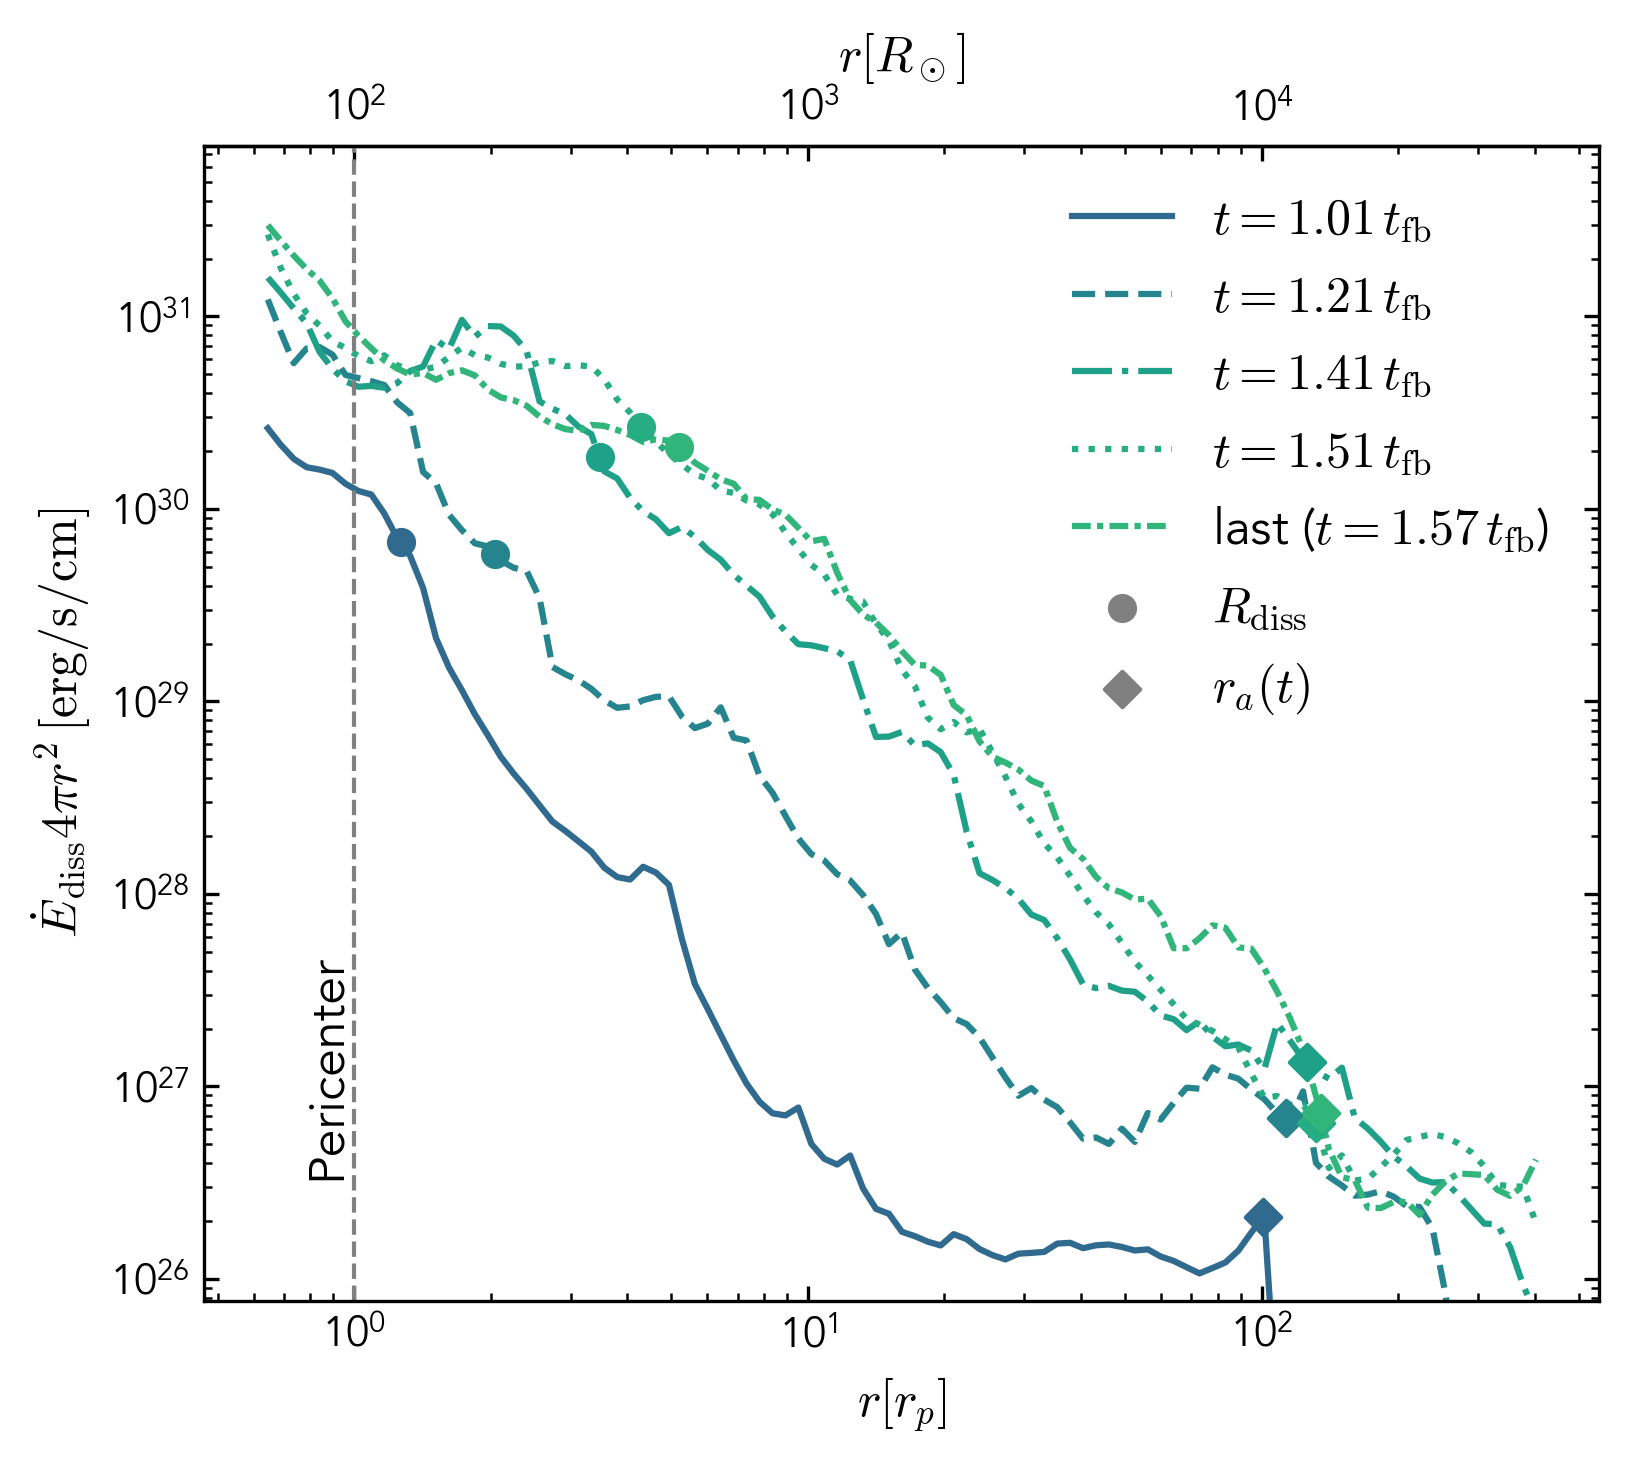

In [11]:
fig, axes = plt.subplots(figsize=(6, 5), dpi=300)
for index, profile in enumerate(profiles_1e6):
    color = tfb_cmap(tfb_norm(profile["time_tfb"]))
    linestyle = line_styles[index % len(line_styles)]
    label = (
        rf"last ($t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$)"
        if profile["is_last"]
        else rf"$t={profile['time_tfb']:.2f}\,t_{{\rm fb}}$"
    )
    plt.plot(
        (profile["r"] / tde_1e6.r_p).to_value(), profile["dEdiss_dr"],
        color=color, linestyle=linestyle, linewidth=1.5, label=label,
    )
    plt.scatter(
        (profile["Rdiss"] / tde_1e6.r_p).to_value(),
        profile["dEdiss_dr_at_Rdiss"],
        color=color, marker='o', zorder=3,
    )
    plt.scatter(
        (profile["r_a"] / tde_1e6.r_p).to_value(),
        profile["dEdiss_dr_at_r_a"],
        color=color, marker='D', zorder=3,
    )

plt.scatter([], [], color='gray', marker='o', label=r"$R_\mathrm{diss}$")
plt.scatter([], [], color='gray', marker='D', label=r"$r_a(t)$")
plt.axvline(1, linestyle="--", color='gray')
plt.annotate(
    text=r"Pericenter", xy=(1, 0.3),
    xycoords=("data", "axes fraction"), rotation=90, va="top", ha="right",
)
plt.yscale("log")
plt.xscale("log")
y_max = axes.get_ylim()[1]
axes.set_ylim(y_max / 1e6, y_max)
plt.ylabel(r"$\dot{E}_\mathrm{diss}4\pi r^2\,\mathrm{[erg/s/cm]}$")
plt.xlabel(r"$r[r_p]$")
add_radius_top_axis(axes, tde_1e6.r_p)
plt.legend()
plt.show()